In [104]:
import numpy as np
import matplotlib.pyplot as plt
import os

from RegressionMultivariate.features_normalize import features_normalize_by_std
from RegressionMultivariate.features_normalize import features_normalizes_by_min_max
from RegressionMultivariate.compute_cost_multi import compute_cost_multi
from RegressionMultivariate.gradient_descent_multi import gradient_descent_multi
from RegressionMultivariate.gradient_descent_multi import gradient_descent_multi_with_history
from RegressionMultivariate.normal_eqn import normal_eqn

In [105]:
def costs_from_history(X_b: np.ndarray, y: np.ndarray, thetas: np.ndarray) -> np.ndarray:
    """Calcula o custo J(θ) para cada θ em *thetas*."""
    return np.array([compute_cost_multi(X_b, y, th) for th in thetas])

In [106]:
#Load data
os.makedirs("Figures", exist_ok=True)
data = np.loadtxt('Data/ex1data2.txt', delimiter=',')

In [107]:
X = data[:, :2] 
y = data[:, 2]
m = y.shape[0]

In [108]:
print('Primeiros 10 exemplos de treinamento:')
print(np.column_stack((X[:10], y[:10])))

Primeiros 10 exemplos de treinamento:
[[2.10400e+03 3.00000e+00 3.99900e+05]
 [1.60000e+03 3.00000e+00 3.29900e+05]
 [2.40000e+03 3.00000e+00 3.69000e+05]
 [1.41600e+03 2.00000e+00 2.32000e+05]
 [3.00000e+03 4.00000e+00 5.39900e+05]
 [1.98500e+03 4.00000e+00 2.99900e+05]
 [1.53400e+03 3.00000e+00 3.14900e+05]
 [1.42700e+03 3.00000e+00 1.98999e+05]
 [1.38000e+03 3.00000e+00 2.12000e+05]
 [1.49400e+03 3.00000e+00 2.42500e+05]]


In [109]:
# 3) Normaliza features
X_norm, mu, sigma = features_normalize_by_std(X)
X_b = np.column_stack((np.ones((X_norm.shape[0], 1)), X_norm)) 

In [110]:
# imprime os parâmetros de normalização
print('\nParâmetros de normalização:')
print(f'Média (mu): {mu}')
print(f'Desvio Padrão (sigma): {sigma}')


Parâmetros de normalização:
Média (mu): [2000.68085106    3.17021277]
Desvio Padrão (sigma): [7.86202619e+02 7.52842809e-01]


In [111]:
# 4) Gradient Descent Multivariado
alpha = 0.01
num_iters = 400
theta_gd = np.zeros(X_b.shape[1])

In [112]:
theta_gd, J_history = gradient_descent_multi(X_b, y, theta_gd, alpha, num_iters)
print('\nTheta via Gradient Descent:')
print(theta_gd)


Theta via Gradient Descent:
[334302.06399328  99411.44947359   3267.01285407]


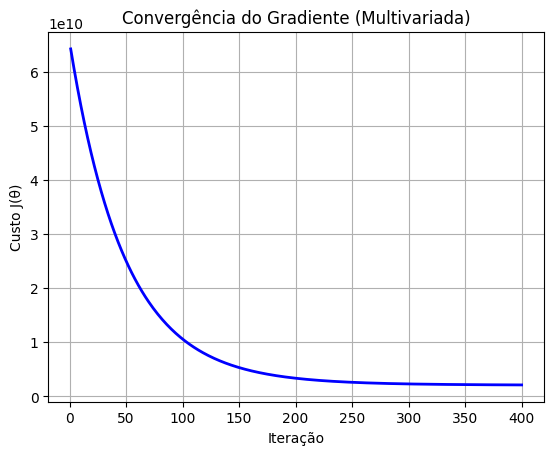

In [113]:
# 4a) Plot de convergência (GD)
plt.figure()
# Coloque o J_history aqui para ser plotado
plt.plot(np.arange(1, num_iters + 1), J_history, 'b-', linewidth=2)
plt.xlabel('Iteração')
plt.ylabel('Custo J(θ)')
plt.title('Convergência do Gradiente (Multivariada)')
plt.grid(True)
#plt.savefig('Figures/convergencia_custo_multi.png', dpi=300, bbox_inches='tight')
#plt.savefig('Figures/convergencia_custo_multi.svg', format='svg', bbox_inches='tight')
plt.show()


In [114]:
# 5) Predição com GD
example = np.array([1650, 3])
example_norm = (example - mu) / sigma
x_pred = np.concatenate(([1], example_norm))
price_gd = x_pred @ theta_gd
print(f'\nPreço previsto (GD) para [1650,3]: ${price_gd:.2f}')


Preço previsto (GD) para [1650,3]: $289221.55


In [115]:
#6) Equação normal
X_ne = np.column_stack((np.ones(X.shape[0]), X))
theta_ne = normal_eqn(X_ne, y)
example = np.array([1, 1650, 3])

In [116]:
#predição com equação normal
price_ne = example @ theta_ne
print('\nTheta via Equação Normal:')
print(theta_ne)
print(f'Preço previsto (NE) para [1650,3]: ${price_ne:.2f}')


Theta via Equação Normal:
[89597.90954355   139.21067402 -8738.01911255]
Preço previsto (NE) para [1650,3]: $293081.46


In [117]:
# 6.1) **Forma errada**: aplicar θ_ne em X_b (normalizado)
#    Isso está **INCORRETO** porque θ_ne foi calculado para X_ne (não normalizado).
cost_ne_errado = compute_cost_multi(X_b, y, theta_ne)
print(f'\n[CUSTO ERRADO] Custo usando θ_ne em X_NORMALIZADO (X_b): {cost_ne_errado:.2f}')


[CUSTO ERRADO] Custo usando θ_ne em X_NORMALIZADO (X_b): 39606006377.94


In [118]:
# 6.2) **Forma correta**: aplicar θ_ne em X_ne (original)
#    Agora θ_ne e X_ne estão na mesma “escala”.
cost_ne_correto = compute_cost_multi(X_ne, y, theta_ne)
print(f'[CUSTO CORRETO] Custo usando θ_ne em X_ORIGINAL (X_ne): {cost_ne_correto:.2f}')

[CUSTO CORRETO] Custo usando θ_ne em X_ORIGINAL (X_ne): 2043280050.60


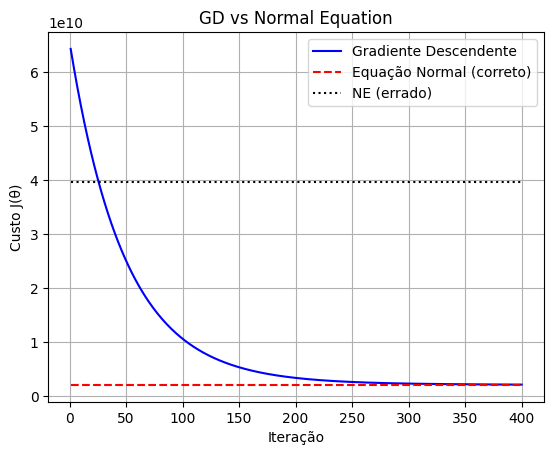

In [119]:
# Também podemos comparar visualmente no gráfico:
plt.figure()
plt.plot(np.arange(1, num_iters + 1), J_history,
         'b-', label='Gradiente Descendente')
plt.hlines(cost_ne_correto, 1, num_iters,
           colors='r', linestyles='--',
           label='Equação Normal (correto)')
# Se quiséssemos, poderíamos plotar também a linha do custo errado:
plt.hlines(cost_ne_errado, 1, num_iters, colors='k', linestyles=':', label='NE (errado)')
plt.xlabel('Iteração')
plt.ylabel('Custo J(θ)')
plt.title('GD vs Normal Equation')
plt.legend()
plt.grid(True)
#plt.savefig('Figures/convergencia_custo_vs_ne.png', dpi=300, bbox_inches='tight')
#plt.savefig('Figures/convergencia_custo_vs_ne.svg', format='svg', bbox_inches='tight')
plt.show()

In [135]:
# -------------- Visualizações 3D / Contorno para multivariada ----------------------------
# Para visualizar a função de custo J(θ) em 3D ou contorno, precisamos
# você precisa implementar a função compute_cost_multi_with_history, que calcula o custo
# e armazena o histórico de parâmetros θ em cada iteração.
# A função compute_cost_multi_with_history é semelhante à função compute_cost_multi,
theta_gd, J_history, theta_history = gradient_descent_multi_with_history(X_b, y, np.zeros(X_b.shape[1]), alpha, num_iters)
theta_ne_norm = theta_gd

In [136]:
# 7) Contorno J(θ1, θ2) (θ0 fixo em θ_gd[0]). Malha de custo centrada no ótimo
t1_hist, t2_hist = theta_history[:, 1], theta_history[:, 2]
max_dev1 = np.max(np.abs(t1_hist - theta_ne_norm[1]))
max_dev2 = np.max(np.abs(t2_hist - theta_ne_norm[2]))
span1 = span2 = 1.5 * max(max_dev1, max_dev2)  # mesma escala nos 2 eixos

t1_vals = np.linspace(theta_ne_norm[1] - span1, theta_ne_norm[1] + span1, 120)
t2_vals = np.linspace(theta_ne_norm[2] - span2, theta_ne_norm[2] + span2, 120)
T1, T2 = np.meshgrid(t1_vals, t2_vals)

J_mesh = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        J_mesh[i, j] = compute_cost_multi(X_b, y, [theta_ne_norm[0], T1[i, j], T2[i, j]])

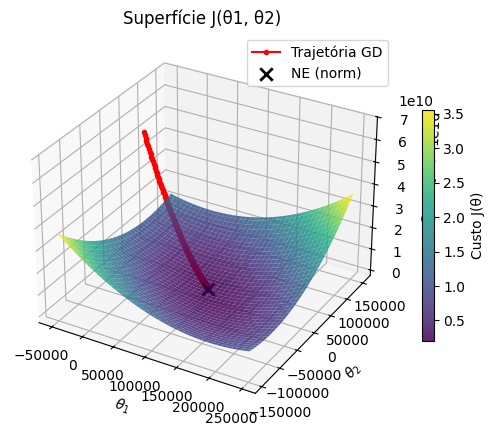

In [137]:
# 8) Superfície J(θ1, θ2) + trajetória GD + NE (normalizado)
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(T1, T2, J_mesh, cmap="viridis", alpha=0.85, linewidth=0)
ax.plot(t1_hist, t2_hist, costs_from_history(X_b, y, theta_history), "r.-", label="Trajetória GD")
ax.scatter(theta_ne_norm[1], theta_ne_norm[2], compute_cost_multi(X_b, y, theta_ne_norm),
           s=80, marker="x", color="black", linewidths=2, label="NE (norm)")
fig.colorbar(surf, ax=ax, shrink=0.6, label="Custo J(θ)")
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$"); ax.set_zlabel("Custo J(θ)")
ax.set_title("Superfície J(θ1, θ2)")
ax.view_init(elev=30, azim=-60)
ax.legend()
#fig.savefig("Figures/superficie_GD_vs_NE.png", dpi=300)

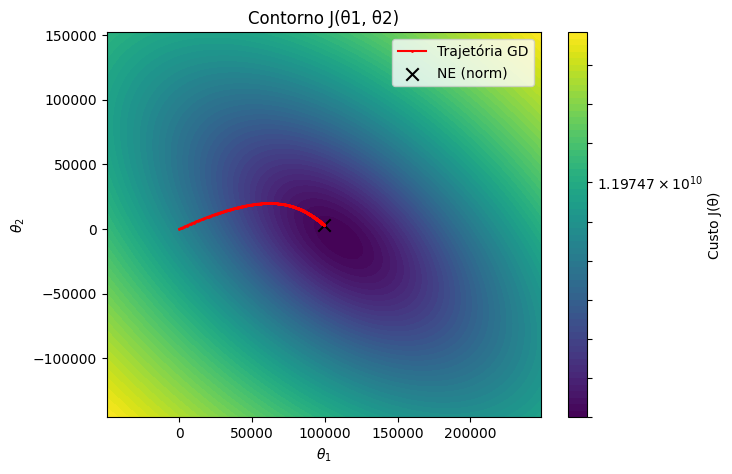

In [138]:
# --------------------------------------------------------------
# 8a) Contorno J(θ1, θ2) + trajetória GD + NE (normalizado)
# O gráfico de contorno é uma projeção 2D da superfície 3D
from matplotlib.colors import LogNorm
plt.figure(figsize=(7, 5))
levels = np.logspace(np.log10(J_mesh.min()), np.log10(J_mesh.max()), 60)
cf = plt.contourf(T1, T2, J_mesh, levels=levels, norm=LogNorm(), cmap="viridis")
plt.colorbar(cf, label="Custo J(θ)")
plt.plot(t1_hist, t2_hist, "r.-", ms=2, label="Trajetória GD")
plt.scatter(theta_ne_norm[1], theta_ne_norm[2], s=80, marker="x", color="black", label="NE (norm)")
plt.xlabel(r"$\theta_1$"); plt.ylabel(r"$\theta_2$")
plt.title("Contorno J(θ1, θ2)"); plt.legend()
#plt.savefig("Figures/contorno_GD_vs_NE.png", dpi=300)
plt.show()

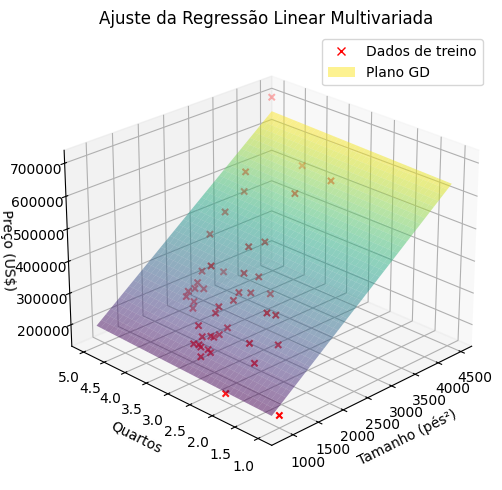

In [139]:
# ------------------------------------------------------------------
# 9) Plano de regressão ajustado + pontos originais (3‑D) ------------
# ------------------------------------------------------------------
fig2 = plt.figure(figsize=(7, 5))
ax2 = fig2.add_subplot(111, projection="3d")

# Pontos originais (feature1 = tamanho; feature2 = quartos)
ax2.scatter(X[:, 0], X[:, 1], y, c="red", marker="x", label="Dados de treino")

# Plano de regressão (usando θ_gd já calculado no início do script)
# Gera malha nas escalas originais (não normalizadas)
f1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 40)
f2_vals = np.linspace(X[:, 1].min(), X[:, 1].max(), 40)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# Precisamos do θ na escala original → convertemos θ_gd (normalizado) para original
theta_gd_orig = np.zeros_like(theta_ne)
theta_gd_orig[1:] = theta_gd[1:] / sigma  # coeficientes revertidos
theta_gd_orig[0] = theta_gd[0] - np.sum((mu / sigma) * theta_gd[1:])  # intercepto

Z = theta_gd_orig[0] + theta_gd_orig[1] * F1 + theta_gd_orig[2] * F2
surf2 = ax2.plot_surface(
    F1, F2, Z, alpha=0.5, cmap="viridis", rstride=1, cstride=1
)

ax2.set_xlabel("Tamanho (pés²)")
ax2.set_ylabel("Quartos")
ax2.set_zlabel("Preço (US$)")
ax2.set_title("Ajuste da Regressão Linear Multivariada")
ax2.view_init(elev=25, azim=-135)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

handles = [
    Line2D([], [], color="red", marker="x", linestyle="", label="Dados de treino"),
    Patch(facecolor=surf2.get_facecolor()[0], edgecolor="none", alpha=0.5, label="Plano GD"),
]
ax2.legend(handles=handles)
fig2.tight_layout()
#fig2.savefig("Figures/ajuste_regressao_multivariada.png", dpi=300)
plt.show()